In [30]:
#Khởi tạo và import thư viện
!git clone https://github.com/levandinhhuy/mlAssignments.git
!cd mlAssignments && git lfs pull

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input

fatal: destination path 'mlAssignments' already exists and is not an empty directory.


In [38]:
#Đường dẫn đến thư mục ảnh, và file chứa nhãn
base_dir = "mlAssignments/Assignment3/data"
csv_path = os.path.join(base_dir, "train.csv")
image_dir = os.path.join(base_dir, "PaddyDisease")

Số lượng mẫu (số lượng ảnh): 10407

 Bảng thống kê số lượng ảnh cho mỗi lớp:

| Lớp                      |   Số lượng ảnh |
|:-------------------------|---------------:|
| normal                   |           1764 |
| blast                    |           1738 |
| hispa                    |           1594 |
| dead_heart               |           1442 |
| tungro                   |           1088 |
| brown_spot               |            965 |
| downy_mildew             |            620 |
| bacterial_leaf_blight    |            479 |
| bacterial_leaf_streak    |            380 |
| bacterial_panicle_blight |            337 |




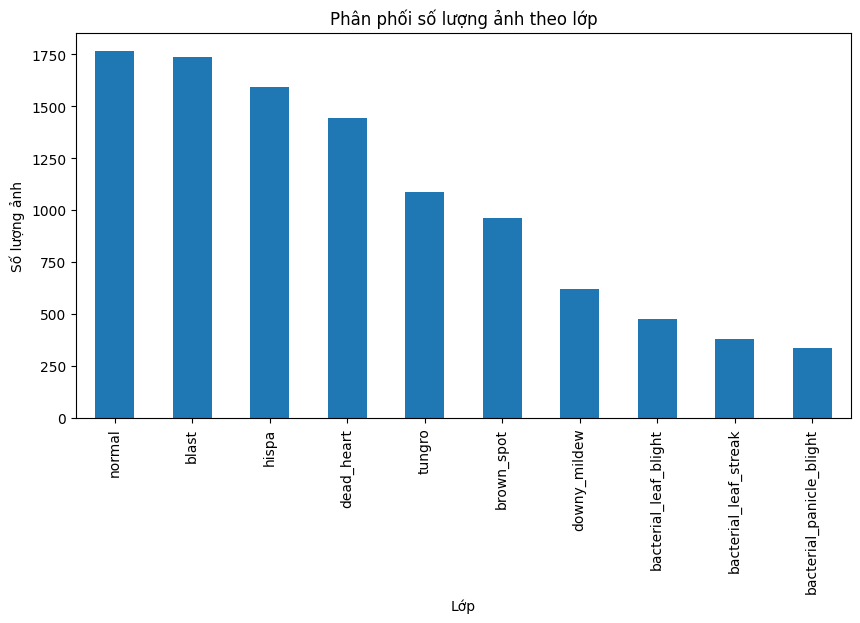

In [39]:
#Đọc file csv để thống kê số lượng mẫu
df = pd.read_csv(csv_path)
print("Số lượng mẫu (số lượng ảnh):", len(df))

#Bảng thống kê số lượng ảnh cho mỗi lớp
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Lớp', 'Số lượng ảnh']
print("\n Bảng thống kê số lượng ảnh cho mỗi lớp:\n")
print(label_counts.to_markdown(index=False))
print("\n")

#Thống kê phân phối nhãn
plt.figure(figsize=(10,5))
df['label'].value_counts().plot(kind='bar')
plt.title("Phân phối số lượng ảnh theo lớp")
plt.xlabel("Lớp")
plt.ylabel("Số lượng ảnh")
plt.show()

Chiều rộng nhỏ nhất: 480
Chiều rộng lớn nhất: 640
Chiều cao nhỏ nhất: 480
Chiều cao lớn nhất: 640
Counter({(480, 640): 10403, (640, 480): 4})


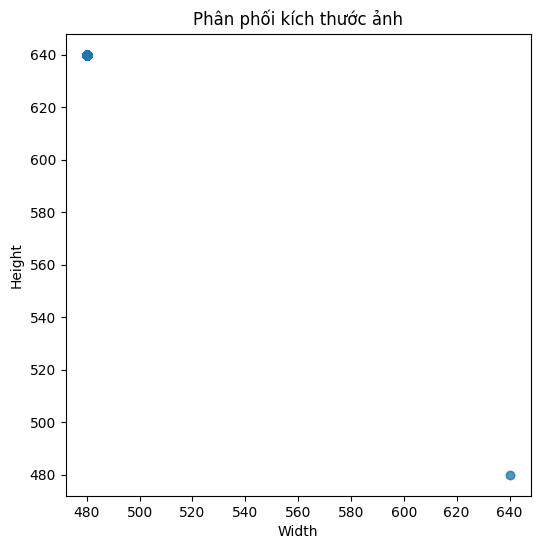

In [40]:
#Thống kê kích thước ảnh
widths = []
heights = []

for img_name in df['image_id']:
    img_path = os.path.join(image_dir, img_name)
    
    img = Image.open(img_path)
    w, h = img.size
    
    widths.append(w)
    heights.append(h)

print("Chiều rộng nhỏ nhất:", min(widths))
print("Chiều rộng lớn nhất:", max(widths))

print("Chiều cao nhỏ nhất:", min(heights))
print("Chiều cao lớn nhất:", max(heights))
#print("Số ảnh đã xử lý:", len(widths))

#Thống kê phân phối kích thước ảnh
from collections import Counter

sizes = list(zip(widths, heights))
print(Counter(sizes))

plt.figure(figsize=(6,6))
plt.scatter(widths, heights, alpha=0.3)
plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Phân phối kích thước ảnh")
plt.show()

Dataset gần như đồng nhất kích thước, tuy nhiên cần resize trước khi train model

In [41]:
#Thống kê số lượng kênh màu
channels = []

for img_name in df['image_id'][:200]:   # kiểm tra 200 ảnh đầu cho nhanh
    img_path = os.path.join(image_dir, img_name)
    
    img = Image.open(img_path)
    channels.append(img.mode)

print("Các loại kênh màu trong dataset:")
print(set(channels))

Các loại kênh màu trong dataset:
{'RGB'}


Data set đều là ảnh màu 3 channel

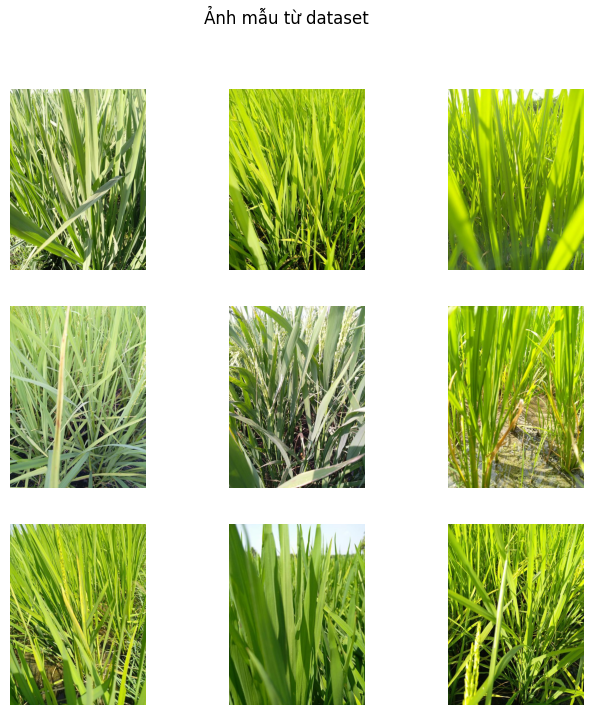

In [42]:
#Hiển thị một số ảnh mẫu từ dataset
import random

sample_images = random.sample(list(df['image_id']), 9)

plt.figure(figsize=(8,8))

for i, img_name in enumerate(sample_images):
    
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)
    
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle("Ảnh mẫu từ dataset")
plt.show()

In [43]:
#Kiểm tra ảnh lỗi
broken_images = []

for img_name in df['image_id']:
    
    img_path = os.path.join(image_dir, img_name)
    
    try:
        img = Image.open(img_path)
        img.verify()
        
    except:
        broken_images.append(img_name)

print("Số ảnh lỗi:", len(broken_images))

Số ảnh lỗi: 0


In [44]:
#1 Khai báo đường dẫn
batch_size = 32

#2 Đọc dataset
df = pd.read_csv(csv_path)

#3 Clean dữ liệu
df = df.dropna(subset=["image_id", "label"])

df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(image_dir, x)
)

# Chỉ giữ ảnh tồn tại
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

#4 Encode label
class_names = sorted(df["label"].unique())

label_to_index = {name: i for i, name in enumerate(class_names)}

df["label_index"] = df["label"].map(label_to_index)

#5 Lưu dataset đã clean
df[["image_id", "label", "label_index"]].to_csv("train_cleaned.csv", index=False)

print("Saved cleaned dataset -> train_cleaned.csv")

#6 Split dataset (80 / 10 / 10)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label_index"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label_index"],
    random_state=42
)

print("Total:", len(df))
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

#7 Hàm load và preprocess ảnh
def load_preprocess(path, label):

    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    img = tf.image.resize(img, (224,224))

    img = preprocess_input(img)

    return img, label

#8 Hàm tạo dataset
def make_dataset(dataframe, shuffle=False):

    paths = dataframe["image_path"].values
    labels = dataframe["label_index"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        lambda x,y: load_preprocess(x,y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe))

    ds = ds.batch(batch_size)

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds



#9 Tạo dataset cho training
train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print("Classes:", class_names)

Saved cleaned dataset -> train_cleaned.csv
Total: 10407
Train: 8325
Validation: 1041
Test: 1041
Classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']


In [45]:
output_dir = "mlAssignments/Assignment3/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

# Lưu các file CSV đã chia
train_df[["image_id", "label", "label_index"]].to_csv(
    os.path.join(output_dir, "train_cleaned.csv"), index=False
)
val_df[["image_id", "label", "label_index"]].to_csv(
    os.path.join(output_dir, "valid.csv"), index=False
)
test_df[["image_id", "label", "label_index"]].to_csv(
    os.path.join(output_dir, "test.csv"), index=False
)
print("Saved CSV files to:", output_dir)

Saved CSV files to: mlAssignments/Assignment3/notebooks/data


In [46]:
import os

print(os.path.exists(os.path.join(output_dir, "train_cleaned.csv")))
print(os.path.exists(os.path.join(output_dir, "valid.csv")))
print(os.path.exists(os.path.join(output_dir, "test.csv")))
print(os.listdir(output_dir))
print(os.path.abspath(output_dir))

True
True
True
['test.csv', 'train_cleaned.csv', 'valid.csv']
/content/mlAssignments/Assignment3/notebooks/data


In [47]:
output_dir = "mlAssignments/Assignment3/notebooks/data"
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(os.path.join(output_dir, "train_cleaned.csv"), index=False)
val_df.to_csv(os.path.join(output_dir, "valid.csv"), index=False)
test_df.to_csv(os.path.join(output_dir, "test.csv"), index=False)

print("Saved to:", os.path.abspath(output_dir))

Saved to: /content/mlAssignments/Assignment3/notebooks/data
